In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Data Exploration
* Duplication
* Missing Values
* Columns data type
* Summary statistics 
* Outliers 

* Duplicationrs 

In [5]:
print('duplicate values : ' , df.duplicated().sum())

duplicate values :  0


* Missing Values

In [6]:
print('null values : \n' , df.isnull().sum())

null values : 
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


* Columns data type

In [7]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

* Outliers 

In [8]:
def remove_outliers_iqr(df):
    df_cleaned = df.copy()       
    for column in df_cleaned.columns:
        Q1 = df_cleaned[column].quantile(0.25)
        Q3 = df_cleaned[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_cleaned = df_cleaned[ (df_cleaned[column] >= lower_bound) & (df_cleaned[column] <= upper_bound) ]
    return df_cleaned


df_cleaned = remove_outliers_iqr(df)

print(f"Original number of records : {df.shape[0]}")
print(f"Number of records after removing outliers : {df_cleaned.shape[0]}")


Original number of records : 768
Number of records after removing outliers : 636


In [10]:
df_cleaned.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
5,5,116,74,0,0,25.6,0.201,30,0


In [11]:
df_cleaned.to_csv('cleaned_data.csv', index=False)

# Data Visualizations

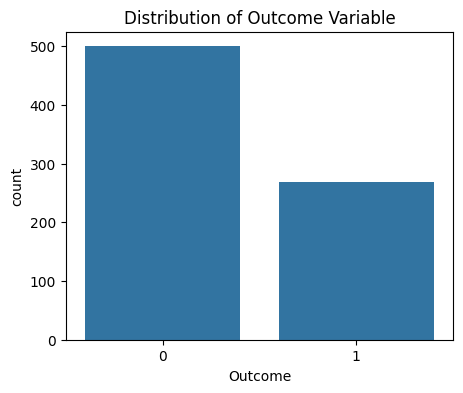

In [12]:
plt.figure(figsize=(5, 4))

sns.countplot(x='Outcome', data=df)
plt.title('Distribution of Outcome Variable')
plt.show()


In [13]:
fig = px.histogram(df, x='Glucose', title='Distribution of Glucose Levels')
fig.show()

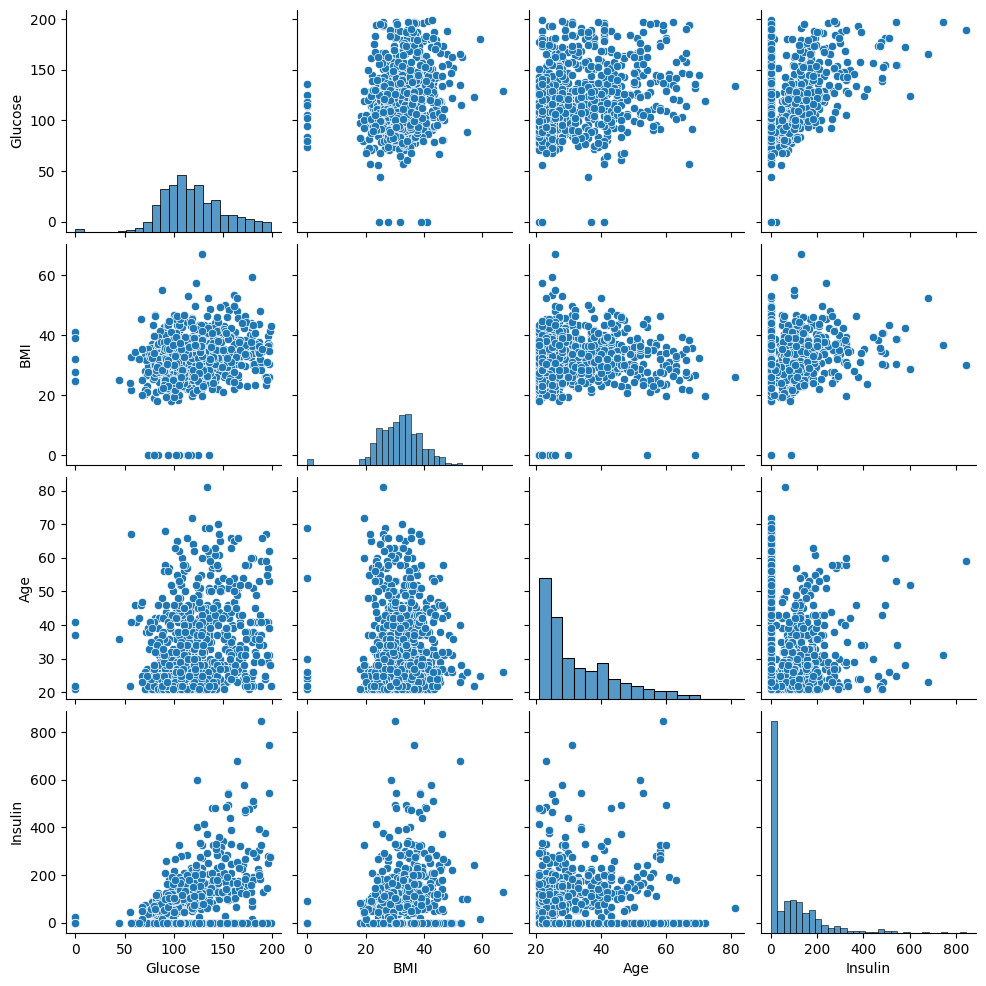

In [14]:
sns.pairplot(df[['Glucose', 'BMI', 'Age', 'Insulin']])
plt.show()


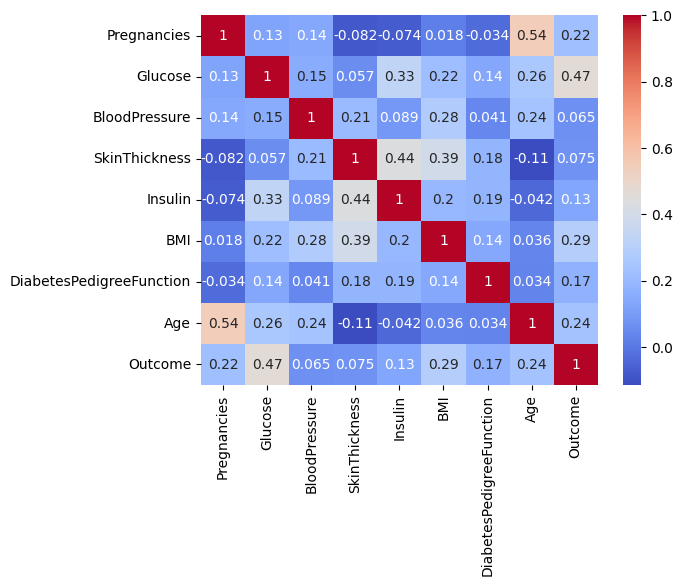

In [15]:
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


In [16]:
average_bmi = df.groupby('Outcome')['BMI'].mean().reset_index()

plt.figure(figsize=(10, 8))

fig = px.bar(average_bmi, x='Outcome', y='BMI',
             title='Average BMI by Outcome',
             labels={'Outcome': 'Diabetes Outcome', 'BMI': 'Average BMI'})

fig.update_traces(text=average_bmi['BMI'], textposition='outside')

fig.update_layout(
    xaxis_title = 'Diabetes Outcome',
    yaxis_title = 'Average BMI',
    title       = 'Average BMI by Outcome',
    height      =  600,
    width       =  600 
)

fig.show()


<Figure size 1000x800 with 0 Axes>

In [17]:
average_bmi = df.groupby('Outcome')['Age'].mean().reset_index()

plt.figure(figsize=(10, 8))

fig = px.bar(average_bmi, x='Outcome', y='Age',
             title='Average Age by Outcome',
             labels={'Outcome': 'Diabetes Outcome', 'Age': 'Average Age'})

fig.update_traces(text=average_bmi['Age'], textposition='outside')

fig.update_layout(
    xaxis_title = 'Diabetes Outcome',
    yaxis_title = 'Average Age',
    title       = 'Average Age by Outcome',
    height      =  600,
    width       =  600 
)

fig.show()


<Figure size 1000x800 with 0 Axes>

In [18]:
fig = px.bar(df, x='Age', y="BMI", title='BMI By Age',
              color_discrete_sequence=px.colors.qualitative.Dark2)

fig.update_layout(
    template='seaborn')

fig.show()